In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv('loan_approval_dataset.csv')
df

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No
...,...,...,...,...,...,...,...,...,...
995,22,49241,500,41020,24 months,Self-Employed,Owned,No,Yes
996,40,116214,423,12415,48 months,Self-Employed,Owned,No,Yes
997,27,64569,300,28155,36 months,Self-Employed,Rented,Yes,Yes
998,61,31745,490,48884,12 months,Self-Employed,Mortgage,No,Yes


In [5]:
df.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [6]:
x=df.drop(columns='Loan_Approved')
y=df['Loan_Approved']

In [7]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [8]:
# model=LogisticRegression()
# model.fit(xtrain,ytrain)     
''' Value Error:
    becoz model understand only numerical values not string values'''

' Value Error:\n    becoz model understand only numerical values not string values'

In [9]:
x.corr(numeric_only=True)  # model will not going to be overfit.

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [10]:
num_col=x.select_dtypes(include='number').columns
# cat_col=df.select_dtypes(exclude='number')
obj_col=x.select_dtypes(include='object').columns

In [11]:
num_col
obj_col

Index(['Loan_Term', 'Employment_Status', 'Residence_Type', 'Previous_Default'], dtype='object')

In [12]:
x[obj_col].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

<Axes: >

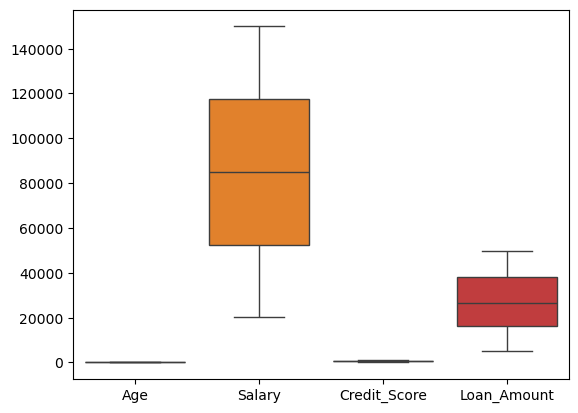

In [13]:
sns.boxplot(x[num_col])

## Preprocessing Techniques:
|__ scaling

|__ encoding

### why scaling?
when we have different range of values we use scaling.
Here,In this dataset we use MinMaxScalar becoz no outliers are present.

### Why encoding?
In this dataset it consists of categorical columns so we use encoding.
Here, In this dataset we use OneHotencoder becoz of less unique values and consists of multiple features.

In [14]:
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')

In [15]:
# xtrain[obj_col]=encoder.fit_transform(xtrain[obj_col])   # Error becoz it assign extra columns

encoded_values=encoder.fit_transform(xtrain[obj_col])
encoded_columns=encoder.get_feature_names_out()

xtrain[encoded_columns]=encoded_values
xtrain.drop(columns=obj_col,inplace=True)

In [16]:
pd.DataFrame(xtrain,columns=xtrain.columns)

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,44,85441,507,17109,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,38,87298,489,10776,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,45,49629,762,39441,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,47,75337,809,40596,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,46,101121,504,31956,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,52,118723,689,31649,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,26,135654,388,22514,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,64,135005,683,8642,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,26,47856,841,45697,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [17]:
encoded_values=encoder.transform(xtest[obj_col])
encoded_columns=encoder.get_feature_names_out()

xtest[encoded_columns]=encoded_values
xtest.drop(columns=obj_col,inplace=True)

In [18]:
scaling=MinMaxScaler()

In [19]:
xtrain[num_col]=scaling.fit_transform(xtrain[num_col])

In [20]:
columns=scaling.get_feature_names_out()

In [21]:
xtest[num_col]=scaling.transform(xtest[num_col])

In [22]:
pd.DataFrame(xtrain[num_col],columns=columns)

,Age,Salary,Credit_Score,Loan_Amount
29,0.565217,0.503206,0.377737,0.267437
535,0.434783,0.517503,0.344891,0.125955
695,0.586957,0.227507,0.843066,0.766342
557,0.630435,0.425421,0.928832,0.792145
836,0.608696,0.623919,0.372263,0.599124
...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266
270,0.173913,0.889773,0.160584,0.388186
860,1.000000,0.884776,0.698905,0.078281
435,0.173913,0.213857,0.987226,0.906103


In [23]:
# model=LogisticRegression(penalty='l1',solver='liblinear')
''' Here,we should not use penalty becoz already variance is low.'''

model=LogisticRegression(penalty=None)     # None = "l2"

In [24]:
model.fit(xtrain,ytrain)

c:\Users\chand\anaconda3\Edunet\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

## Metrics

### 1. confusion metric

### Train Data Evaluation

In [25]:
from sklearn.metrics import confusion_matrix,precision_score,recall_score,accuracy_score,f1_score
import numpy as np

In [26]:
ytrain_pred=model.predict(xtrain)
ytest_pred=model.predict(xtest)
# ytrain_pred

In [27]:
ytrain.value_counts()      

Loan_Approved
Yes    403
No     397
Name: count, dtype: int64

Here Data set is balanced.

In [28]:
matrix=confusion_matrix(ytrain,ytrain_pred)
matrix

array([[205, 192],
       [171, 232]], dtype=int64)

Out of all the samples 397 , 205 are predicted as correctly ('No') and 192 are predicted as wrongly ("Yes").

Out of all the samples 403 , 233 are predicted as correctly ("No") and 170 are predicted as wrongly ("Yes").


### 2. Precison Score

In [29]:
# For positive
precision_score(ytrain,ytrain_pred,pos_label='Yes')

0.5471698113207547

In [30]:
predicted_yes=np.sum(matrix[:,1])
predicted_yes                      # (192 + 233)
predicted_no=np.sum(matrix[:,0])
predicted_no                       # (205 + 170)

376

In [31]:
"""
conclusion:
        out of all the predicted 'yes' labels(425) , i.e 54% labels are correctly predicted as 'yes'.
  
        out of all the predicted 'yes' labels(425) , i.e 46% labels are wrongly predicted as 'yes'.

"""

"\nconclusion:\n        out of all the predicted 'yes' labels(425) , i.e 54% labels are correctly predicted as 'yes'.\n  \n        out of all the predicted 'yes' labels(425) , i.e 46% labels are wrongly predicted as 'yes'.\n\n"

In [32]:
# For negative
precision_score(ytrain,ytrain_pred,pos_label='No')

0.5452127659574468

In [33]:
"""
conclusion:
        out of all the predicted 'yes' labels(375) , i.e 54% labels are correctly predicted as 'yes'.
  
        out of all the predicted 'yes' labels(375) , i.e 46% labels are wrongly predicted as 'yes'.

"""

"\nconclusion:\n        out of all the predicted 'yes' labels(375) , i.e 54% labels are correctly predicted as 'yes'.\n  \n        out of all the predicted 'yes' labels(375) , i.e 46% labels are wrongly predicted as 'yes'.\n\n"

### 3. Recall Score

In [34]:
recall_score(ytrain,ytrain_pred,pos_label='Yes')

0.575682382133995

In [35]:
"""
conclusion:
        out of all the actual predicted 'yes' labels(403) , i.e 57% labels are correctly predicted as 'yes'.
  
        out of all the actual predicted 'yes' labels(403) , i.e 43% labels are wrongly predicted as 'No'.

"""

"\nconclusion:\n        out of all the actual predicted 'yes' labels(403) , i.e 57% labels are correctly predicted as 'yes'.\n  \n        out of all the actual predicted 'yes' labels(403) , i.e 43% labels are wrongly predicted as 'No'.\n\n"

In [36]:
recall_score(ytrain,ytrain_pred,pos_label='No')

0.5163727959697733

In [37]:
"""
conclusion:
        out of all the actual predicted 'No' labels(397) , i.e 51% labels are correctly predicted as 'No'.
  
        out of all the actual predicted 'No' labels(397) , i.e 49% labels are wrongly predicted as 'Yes'.

"""

"\nconclusion:\n        out of all the actual predicted 'No' labels(397) , i.e 51% labels are correctly predicted as 'No'.\n  \n        out of all the actual predicted 'No' labels(397) , i.e 49% labels are wrongly predicted as 'Yes'.\n\n"

### 4. Accuracy Score

In [38]:
"""Train score"""
accuracy_score(ytrain,ytrain_pred)

0.54625

In [39]:
ytrain.count().sum()

800

In [40]:
"""
conclusion:
        out of all the samples(800), 54.75% of samples are correctly predicted .

Final conclusion:
        Model performance on train data is bad, so model is not learned train data patterns properly. 
"""

'\nconclusion:\n        out of all the samples(800), 54.75% of samples are correctly predicted .\n\nFinal conclusion:\n        Model performance on train data is bad, so model is not learned train data patterns properly. \n'

In [41]:
"""Test Score"""
accuracy_score(ytest,ytest_pred)

0.5

In [42]:
"""
conclusion:
        out of all the samples(800), 49.50% of samples are correctly predicted .

Final conclusion:
        Model performance on test data is bad, so model is not learned train data patterns properly. 
(***IMP***) --> It Means model is underfit.
"""

'\nconclusion:\n        out of all the samples(800), 49.50% of samples are correctly predicted .\n\nFinal conclusion:\n        Model performance on test data is bad, so model is not learned train data patterns properly. \n(***IMP***) --> It Means model is underfit.\n'

In [43]:
from sklearn.metrics import classification_report

In [44]:
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

          No       0.55      0.52      0.53       397
         Yes       0.55      0.58      0.56       403

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800



In [45]:
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

          No       0.47      0.49      0.48        95
         Yes       0.52      0.50      0.51       105

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.50      0.50       200

